In [3]:
import numpy as np
import pandas as pd

In [4]:
hospital_data = pd.read_csv('hospital_patient_analytics.csv', index_col='Patient_ID')

In [5]:
hospital_data

,Admission_Date,Discharge_Date,Department,Admission_Type,Diagnosis,Severity_Level,Age,Insurance_Type,Length_of_Stay_Days,Total_Charges,Insurance_Coverage,Wait_Time_Hours,Number_of_Procedures,Staff_to_Patient_Ratio,Patient_Satisfaction_Score,Complications,Readmitted_30Days
Patient_ID,,,,,,,,,,,,,,,,,
PT10001,17/05/2024,01/06/2024,Internal Medicine,Emergency,Pneumonia,Critical,43,HMO,15,55123.81,41401.12,7.8,1,3.8,5.9,1,0
PT10002,30/08/2024,12/09/2024,General Surgery,Emergency,Tumor Removal,High,23,Medicaid,13,48610.53,31031.31,4.3,1,2.9,5.8,0,0
PT10003,13/04/2023,16/04/2023,Oncology,Urgent,Colon Cancer,Moderate,79,Medicare,3,15424.65,12306.39,3.9,0,1.8,6.6,0,0
PT10004,09/12/2024,15/12/2024,Orthopedics,Elective,Sports Injury,Low,44,Medicare,6,23061.36,16114.01,0.4,4,2.6,9.1,0,0
PT10005,09/04/2024,15/04/2024,Orthopedics,Emergency,Joint Replacement,High,30,HMO,6,29412.57,20775.83,3.5,3,2.1,8.5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PT10226,12/03/2023,16/03/2023,Pediatrics,Elective,Ear Infection,Moderate,17,PPO,4,11193.92,8812.49,0.8,2,2.6,6.2,0,0
PT10227,13/07/2024,15/07/2024,Orthopedics,Elective,Spinal Injury,Low,18,Medicare,2,10856.01,7406.17,0.8,2,2.0,6.2,0,0
PT10228,20/10/2024,26/10/2024,Internal Medicine,Urgent,COPD,Moderate,55,Private Insurance,6,21767.89,18102.13,0.8,1,2.4,6.3,0,0


In [6]:
hospital_data.info()

<class 'pandas.DataFrame'>
Index: 230 entries, PT10001 to PT10230
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Admission_Date              230 non-null    str    
 1   Discharge_Date              230 non-null    str    
 2   Department                  230 non-null    str    
 3   Admission_Type              230 non-null    str    
 4   Diagnosis                   230 non-null    str    
 5   Severity_Level              230 non-null    str    
 6   Age                         230 non-null    int64  
 7   Insurance_Type              230 non-null    str    
 8   Length_of_Stay_Days         230 non-null    int64  
 9   Total_Charges               230 non-null    float64
 10  Insurance_Coverage          224 non-null    float64
 11  Wait_Time_Hours             230 non-null    float64
 12  Number_of_Procedures        230 non-null    int64  
 13  Staff_to_Patient_Ratio      220 non-null 

I used the mean of the column with missing data to fill up the column 


In [7]:
hospital_data['Insurance_Coverage'].mean()

np.float64(17276.098973214284)

In [8]:
hospital_data[['Insurance_Coverage', 'Staff_to_patient_Ratio', 'Patient_Satisfaction_Score']] = hospital_data[['Insurance_Coverage','Staff_to_Patient_Ratio','Patient_Satisfaction_Score']].fillna(hospital_data[['Insurance_Coverage','Staff_to_Patient_Ratio','Patient_Satisfaction_Score']].mean())

In [9]:
hospital_data.info() # i checked again to be sure all columns are filled up

<class 'pandas.DataFrame'>
Index: 230 entries, PT10001 to PT10230
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Admission_Date              230 non-null    str    
 1   Discharge_Date              230 non-null    str    
 2   Department                  230 non-null    str    
 3   Admission_Type              230 non-null    str    
 4   Diagnosis                   230 non-null    str    
 5   Severity_Level              230 non-null    str    
 6   Age                         230 non-null    int64  
 7   Insurance_Type              230 non-null    str    
 8   Length_of_Stay_Days         230 non-null    int64  
 9   Total_Charges               230 non-null    float64
 10  Insurance_Coverage          230 non-null    float64
 11  Wait_Time_Hours             230 non-null    float64
 12  Number_of_Procedures        230 non-null    int64  
 13  Staff_to_Patient_Ratio      220 non-null 

In [10]:
hospital_data['Patient_Out_of_Pocket'] = hospital_data['Total_Charges'] - hospital_data['Insurance_Coverage']

In [11]:
hospital_data.info()

<class 'pandas.DataFrame'>
Index: 230 entries, PT10001 to PT10230
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Admission_Date              230 non-null    str    
 1   Discharge_Date              230 non-null    str    
 2   Department                  230 non-null    str    
 3   Admission_Type              230 non-null    str    
 4   Diagnosis                   230 non-null    str    
 5   Severity_Level              230 non-null    str    
 6   Age                         230 non-null    int64  
 7   Insurance_Type              230 non-null    str    
 8   Length_of_Stay_Days         230 non-null    int64  
 9   Total_Charges               230 non-null    float64
 10  Insurance_Coverage          230 non-null    float64
 11  Wait_Time_Hours             230 non-null    float64
 12  Number_of_Procedures        230 non-null    int64  
 13  Staff_to_Patient_Ratio      220 non-null 

In [12]:
hospital_data['Patient_Out_of_Pocket']

Patient_ID
PT10001    13722.69
PT10002    17579.22
PT10003     3118.26
PT10004     6947.35
PT10005     8636.74
             ...   
PT10226     2381.43
PT10227     3449.84
PT10228     3665.76
PT10229     3368.04
PT10230     1510.80
Name: Patient_Out_of_Pocket, Length: 230, dtype: float64

In [13]:
hospital_data.info()

<class 'pandas.DataFrame'>
Index: 230 entries, PT10001 to PT10230
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Admission_Date              230 non-null    str    
 1   Discharge_Date              230 non-null    str    
 2   Department                  230 non-null    str    
 3   Admission_Type              230 non-null    str    
 4   Diagnosis                   230 non-null    str    
 5   Severity_Level              230 non-null    str    
 6   Age                         230 non-null    int64  
 7   Insurance_Type              230 non-null    str    
 8   Length_of_Stay_Days         230 non-null    int64  
 9   Total_Charges               230 non-null    float64
 10  Insurance_Coverage          230 non-null    float64
 11  Wait_Time_Hours             230 non-null    float64
 12  Number_of_Procedures        230 non-null    int64  
 13  Staff_to_Patient_Ratio      220 non-null 

I grouped the data by department to see their patient size, length of stay, total revenue and satisfaction

In [14]:
hospital_data.groupby('Department').agg(
Patient_Count=('Department', 'size'),
Avg_Length_of_Stay=('Length_of_Stay_Days', 'mean'),
Total_Revenue=('Total_Charges', 'sum'),
Avg_Satisfaction=('Patient_Satisfaction_Score', 'mean'))

,Patient_Count,Avg_Length_of_Stay,Total_Revenue,Avg_Satisfaction
Department,,,,
Cardiology,39,6.897436,1090912.88,7.410967
Emergency,32,8.468750,1087010.51,6.552599
General Surgery,29,7.413793,991504.25,7.297508
Internal Medicine,27,6.148148,690842.59,7.552879
Neurology,28,5.392857,731747.75,7.408133
Oncology,34,5.617647,847936.33,6.947874
Orthopedics,23,7.130435,607103.59,7.427292
Pediatrics,18,5.111111,333039.41,7.423763


I also grouped the data by Admission type to see their mean charge, length of stay and wait time 

In [15]:
df = hospital_data.groupby('Admission_Type').agg(
Avg_Charge=('Total_Charges', 'mean'),
Avg_Length_of_Stay=('Length_of_Stay_Days', 'mean'),
Avg_wait_time=('Wait_Time_Hours', 'mean'))
df = df.sort_values(by='Avg_Charge', ascending=False)

df[['Avg_Charge','Avg_Length_of_Stay', 'Avg_wait_time']] = df[['Avg_Charge','Avg_Length_of_Stay', 'Avg_wait_time']].round(2)
print(df)

                Avg_Charge  Avg_Length_of_Stay  Avg_wait_time
Admission_Type                                               
Emergency         42632.58                9.95           4.68
Urgent            21719.01                5.28           2.20
Elective          18914.81                4.59           1.07


Insurance Type Analysis 

In [16]:
hospital_data.loc[hospital_data['Insurance_Type'] == 'Self-Pay','Insurance_Coverage'] = 0

hospital_data['Coverage_Percentage'] = (hospital_data['Insurance_Coverage']/ hospital_data['Total_Charges']) * 100

df = hospital_data.groupby('Insurance_Type').agg(
Avg_Coverage=('Insurance_Coverage', 'mean'),
Avg_Out_of_Pocket=('Patient_Out_of_Pocket', 'mean'),
Coverage_Percentage=('Coverage_Percentage', 'mean'))
df = df.sort_values(by='Avg_Coverage', ascending=False)
df[['Avg_Coverage', 'Avg_Out_of_Pocket', 'Coverage_Percentage']] = df[['Avg_Coverage', 'Avg_Out_of_Pocket', 'Coverage_Percentage']].round(2)
print(df)

                   Avg_Coverage  Avg_Out_of_Pocket  Coverage_Percentage
Insurance_Type                                                         
Medicaid               22455.47            9616.05                70.48
HMO                    21621.01            4159.71                84.92
PPO                    21385.26            5287.73                79.89
Medicare               19176.55            8796.00                70.40
Private Insurance      18770.21            4008.60                82.66
Self-Pay                   0.00           29109.58                 0.00


I grouped the data by department and severity level to see the level of readmission and complication in each department

In [17]:
df = hospital_data.groupby(['Department', 'Severity_Level']).agg(
    Readmission_rate=('Readmitted_30Days', 'sum'),
    complication_rate=('Complications', 'sum'))
print(df)

                                  Readmission_rate  complication_rate
Department        Severity_Level                                     
Cardiology        Critical                       0                  1
                  High                           0                  3
                  Low                            4                  2
                  Moderate                       2                  4
Emergency         Critical                       2                  2
                  High                           2                  4
                  Low                            0                  0
                  Moderate                       2                  1
General Surgery   Critical                       1                  0
                  High                           0                  0
                  Low                            3                  1
                  Moderate                       0                  1
Internal Medicine Cr

I decide to see how the severity level in each department affects the length of stay

In [60]:
df = hospital_data.groupby(['Department', 'Severity_Level']).agg(
    length_of_stay=('Length_of_Stay_Days', 'mean'))
df = df.sort_values(by='Department', ascending=True)
df['length_of_stay'] = df['length_of_stay'].round(2)
print(df)

                                  length_of_stay
Department        Severity_Level                
Cardiology        Critical                 15.00
                  High                     12.20
                  Low                       4.00
                  Moderate                  6.05
Emergency         Critical                 13.25
                  High                      9.15
                  Low                       1.00
                  Moderate                  4.89
General Surgery   Critical                 14.00
                  High                     11.00
                  Low                       4.00
                  Moderate                  6.50
Internal Medicine Low                       2.40
                  Moderate                  3.67
                  Critical                 15.33
                  High                      9.14
Neurology         Critical                 11.33
                  High                      8.75
                  Lo

I had to group the wait time into categories so i can see if the wait time and staff ratio affects the mean satisfaction rate 

In [19]:
wait_bins = [0, 2, 4, 12]
wait_labels = ['≤2hrs', '2-4hrs', '>4hrs']

hospital_data['Wait_Time_Category'] = pd.cut(hospital_data['Wait_Time_Hours'],bins=wait_bins,
labels=wait_labels,right=False)

df = hospital_data.groupby(['Department', 'Wait_Time_Category']).agg(
Avg_Satisfaction=('Patient_Satisfaction_Score', 'mean'),
Avg_Staff_Ratio=('Staff_to_Patient_Ratio', 'mean'))

df[['Avg_Satisfaction', 'Avg_Staff_Ratio']] = df[['Avg_Satisfaction', 'Avg_Staff_Ratio']].round(2)
    

print(df)

                                      Avg_Satisfaction  Avg_Staff_Ratio
Department        Wait_Time_Category                                   
Cardiology        ≤2hrs                           7.31             2.07
                  2-4hrs                          7.45             2.48
                  >4hrs                           8.45             3.00
Emergency         ≤2hrs                           5.68             2.73
                  2-4hrs                          6.63             2.39
                  >4hrs                           6.80             3.07
General Surgery   ≤2hrs                           7.55             2.12
                  2-4hrs                          7.42             2.84
                  >4hrs                           5.95             3.30
Internal Medicine ≤2hrs                           7.31             2.31
                  2-4hrs                          8.39             2.37
                  >4hrs                           7.14          

I made befitting chart for all the grouped data to make it easier to analyse 

In [20]:
import matplotlib as mpl
import matplotlib.pyplot as plt

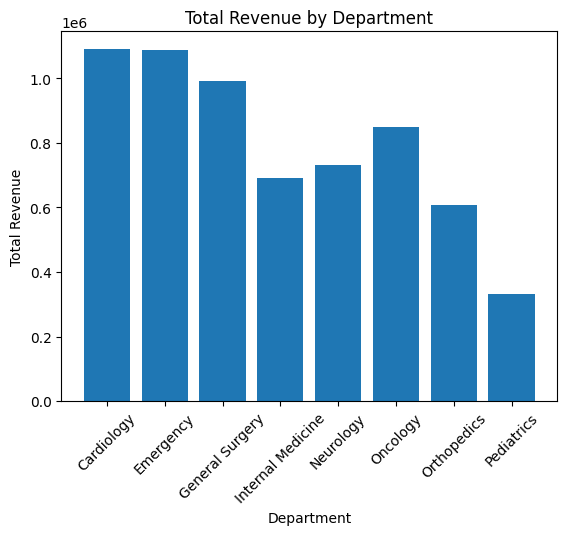

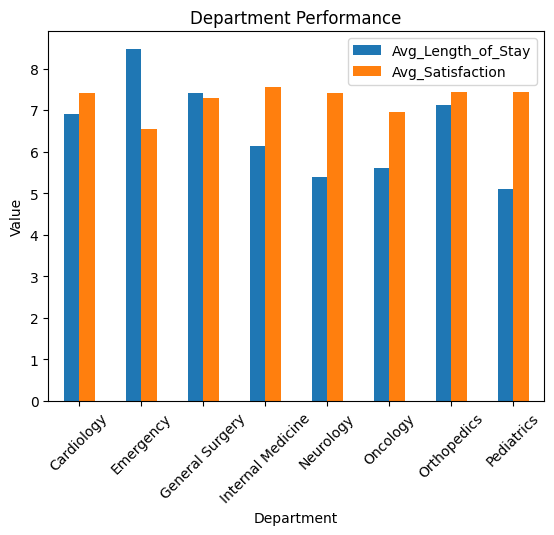

In [68]:
df = hospital_data.groupby('Department').agg(
    Patient_Count=('Department', 'size'),
    Avg_Length_of_Stay=('Length_of_Stay_Days', 'mean'),
    Total_Revenue=('Total_Charges', 'sum'),
    Avg_Satisfaction=('Patient_Satisfaction_Score', 'mean'))

plt.bar(df.index, df['Total_Revenue'])

plt.xlabel('Department')
plt.ylabel('Total Revenue')
plt.title('Total Revenue by Department')

plt.xticks(rotation=45)
plt.show()

df[['Avg_Length_of_Stay', 'Avg_Satisfaction']].plot(kind='bar')
plt.xlabel('Department')
plt.ylabel('Value')
plt.title('Department Performance')

plt.xticks(rotation=45)
plt.show()

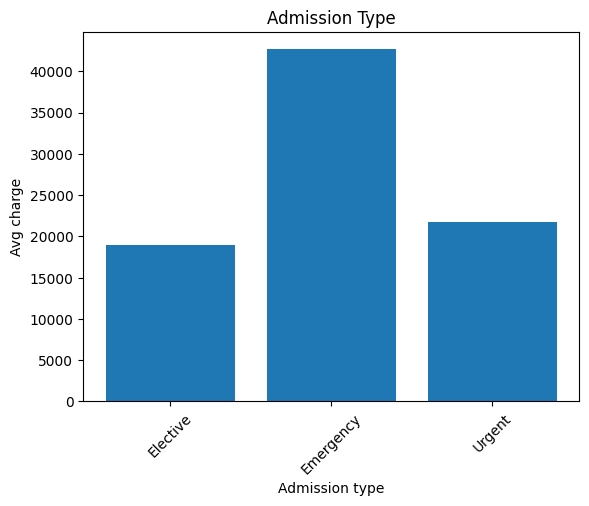

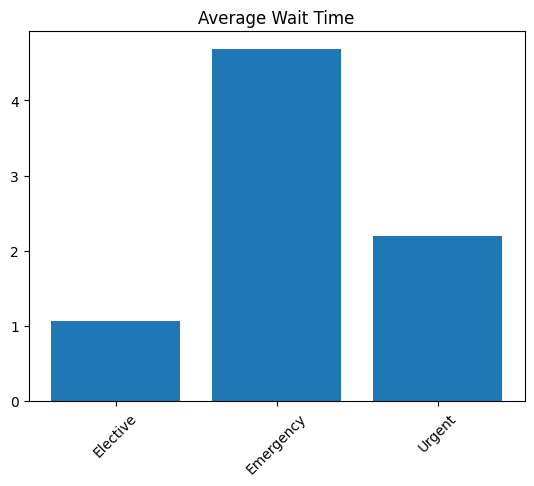

In [44]:
df = hospital_data.groupby('Admission_Type').agg(
Avg_Charge=('Total_Charges', 'mean'),
Avg_Length_of_Stay=('Length_of_Stay_Days', 'mean'),
Avg_wait_time=('Wait_Time_Hours', 'mean'))
plt.bar(df.index, df['Avg_Charge'])

plt.xlabel('Admission type')
plt.ylabel('Avg charge')
plt.title('Admission Type')

plt.xticks(rotation=45)
plt.show()

plt.bar(df.index, df['Avg_wait_time'])
plt.title('Average Wait Time')
plt.xticks(rotation=45)
plt.show()

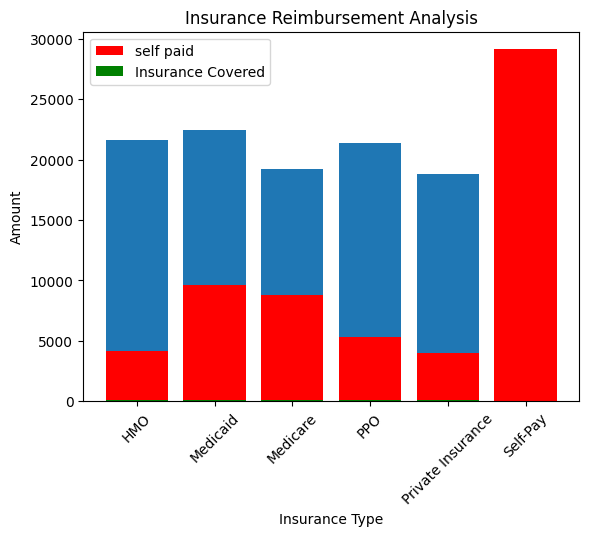

In [66]:
hospital_data.loc[hospital_data['Insurance_Type'] == 'Self-Pay','Insurance_Coverage'] = 0

hospital_data['Coverage_Percentage'] = (hospital_data['Insurance_Coverage']/ hospital_data['Total_Charges']) * 100

df = hospital_data.groupby('Insurance_Type').agg(
Avg_Coverage=('Insurance_Coverage', 'mean'),
Avg_Out_of_Pocket=('Patient_Out_of_Pocket', 'mean'),
Coverage_Percentage=('Coverage_Percentage', 'mean'))

plt.bar(df.index, df['Avg_Coverage'])
plt.bar(df.index, df['Avg_Out_of_Pocket'], label='self paid', color='r')
plt.bar(df.index, df['Coverage_Percentage'], label='Insurance Covered',color='g')

plt.xlabel('Insurance Type')
plt.ylabel('Amount')
plt.title('Insurance Reimbursement Analysis')
plt.legend()
plt.xticks(rotation=45)
plt.show()


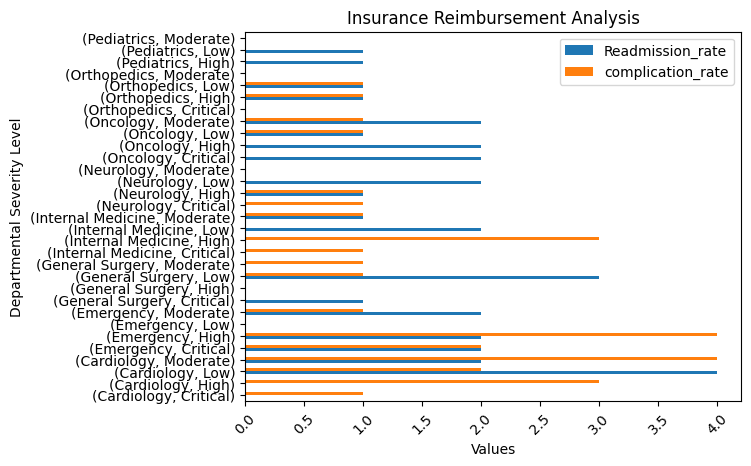

In [57]:
df = hospital_data.groupby(['Department', 'Severity_Level']).agg(
    Readmission_rate=('Readmitted_30Days', 'sum'),
    complication_rate=('Complications', 'sum'))

df[['Readmission_rate', 'complication_rate']].plot(kind='barh')
plt.xlabel('Values')
plt.ylabel('Departmental Severity Level')
plt.title('Insurance Reimbursement Analysis')
plt.legend()
plt.xticks(rotation=45)
plt.show()

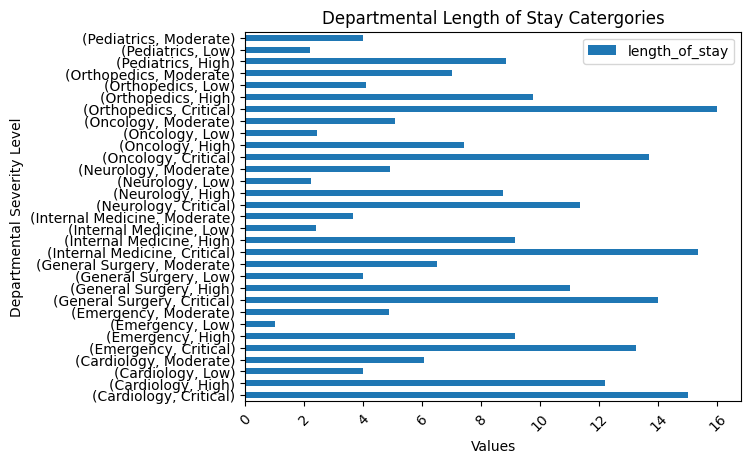

In [63]:
df = hospital_data.groupby(['Department', 'Severity_Level']).agg(
    length_of_stay=('Length_of_Stay_Days', 'mean'))
df['length_of_stay'].plot(kind='barh')
plt.xlabel('Values')
plt.ylabel('Departmental Severity Level')
plt.title('Departmental Length of Stay Catergories')
plt.legend()
plt.xticks(rotation=45)
plt.show()

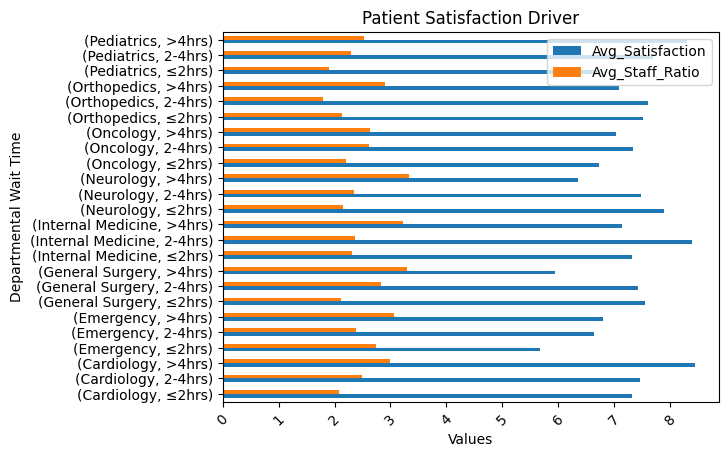

In [65]:
wait_bins = [0, 2, 4, 12]
wait_labels = ['≤2hrs', '2-4hrs', '>4hrs']

hospital_data['Wait_Time_Category'] = pd.cut(hospital_data['Wait_Time_Hours'],bins=wait_bins,
labels=wait_labels,right=False)

df = hospital_data.groupby(['Department', 'Wait_Time_Category']).agg(
Avg_Satisfaction=('Patient_Satisfaction_Score', 'mean'),
Avg_Staff_Ratio=('Staff_to_Patient_Ratio', 'mean'))

df[['Avg_Satisfaction', 'Avg_Staff_Ratio']].plot(kind='barh')
plt.xlabel('Values')
plt.ylabel('Departmental Wait Time')
plt.title('Patient Satisfaction Driver')
plt.legend()
plt.xticks(rotation=45)
plt.show()


The analysis showed that Length of Stay is the primary driver of the hospital total charges, directly impacting the financial KPI, 
while wait time and staffing levels does not necessarily influence patient satisfaction rating. 
Cardiology department has the highest patient count and contributes the most to the total charges, while pediatrics has the least patient count and also the least total charges contribution. 

